In [2]:
!pip install -q pandas numpy scikit-learn nltk spacy gensim matplotlib seaborn
!python -m spacy download pt_core_news_sm


  Using cached https://github.com/explosion/spacy-models/releases/download/pt_core_news_sm-3.8.0/pt_core_news_sm-3.8.0-py3-none-any.whl (13.0 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import spacy

from nltk.corpus import stopwords
from gensim.models import FastText

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

print("Bibliotecas importadas com sucesso.")


Bibliotecas importadas com sucesso.


In [4]:
nltk.download("stopwords", quiet=True)

stop_words_pt = set(stopwords.words("portuguese"))

nlp = spacy.load("pt_core_news_sm")

print("Ambiente preparado com sucesso.")
print(f"Quantidade de stopwords: {len(stop_words_pt)}")


Ambiente preparado com sucesso.
Quantidade de stopwords: 207


In [6]:
import pandas as pd


# ============================================================
# DATASET DE TREINAMENTO
# ============================================================

dados_treino = [

    # --------------------------------------------------------
    # TROCAS E DEVOLUÇÕES
    # --------------------------------------------------------

    ("Quero devolver este sofá que chegou com rasgo",
     "trocas_devolucoes"),

    ("Gostaria de trocar minha mesa que veio arranhada",
     "trocas_devolucoes"),

    ("Como faço para solicitar a devolução do meu estofado?",
     "trocas_devolucoes"),

    ("O rack veio com defeito e quero trocar",
     "trocas_devolucoes"),

    ("Preciso devolver a cadeira de escritório com defeito",
     "trocas_devolucoes"),

    ("Quero cancelar a compra e pedir estorno do sofá",
     "trocas_devolucoes"),

    ("Meu painel de TV veio quebrado e quero trocar",
     "trocas_devolucoes"),

    ("Gostaria de devolver o armário por defeito",
     "trocas_devolucoes"),

    ("Como faço para trocar um móvel que veio danificado?",
     "trocas_devolucoes"),

    ("Quero solicitar a troca da minha estante",
     "trocas_devolucoes"),

    ("O produto chegou diferente do que comprei",
     "trocas_devolucoes"),

    ("Preciso devolver uma cadeira que apresentou defeito",
     "trocas_devolucoes"),

    ("Meu sofá chegou rasgado, como faço a troca?",
     "trocas_devolucoes"),

    ("Quero devolver o produto que recebi",
     "trocas_devolucoes"),

    ("Posso trocar minha mesa de jantar?",
     "trocas_devolucoes"),

    ("Como funciona o processo de devolução?",
     "trocas_devolucoes"),

    ("Quero cancelar meu pedido e devolver o produto",
     "trocas_devolucoes"),

    ("A cama chegou danificada e preciso trocar",
     "trocas_devolucoes"),

    ("Recebi um armário com peças quebradas e quero devolver",
     "trocas_devolucoes"),

    ("Gostaria de saber como solicitar o estorno",
     "trocas_devolucoes"),


    # --------------------------------------------------------
    # LOGÍSTICA E ENTREGAS
    # --------------------------------------------------------

    ("Qual o status da entrega da minha estante?",
     "logistica_entregas"),

    ("Onde está meu pedido de poltrona?",
     "logistica_entregas"),

    ("Qual o prazo de entrega do sofá que comprei?",
     "logistica_entregas"),

    ("Meu armário de cozinha ainda não chegou",
     "logistica_entregas"),

    ("Quero rastrear o transporte da minha mesa de jantar",
     "logistica_entregas"),

    ("A entrega do guarda roupa está atrasada",
     "logistica_entregas"),

    ("Quando chega minha cadeira presidente?",
     "logistica_entregas"),

    ("Quero saber o dia que chegam meus móveis",
     "logistica_entregas"),

    ("Como faço para rastrear meu pedido?",
     "logistica_entregas"),

    ("Onde está minha compra?",
     "logistica_entregas"),

    ("Meu pedido está atrasado",
     "logistica_entregas"),

    ("Quero consultar o status da entrega",
     "logistica_entregas"),

    ("Quando meu sofá será entregue?",
     "logistica_entregas"),

    ("Ainda não recebi minha mesa",
     "logistica_entregas"),

    ("Qual a previsão de chegada do meu pedido?",
     "logistica_entregas"),

    ("Preciso acompanhar a entrega do meu armário",
     "logistica_entregas"),

    ("Minha encomenda ainda não chegou",
     "logistica_entregas"),

    ("Tem como verificar onde está meu pedido?",
     "logistica_entregas"),

    ("Gostaria de saber o prazo de entrega",
     "logistica_entregas"),

    ("Meu pedido já foi enviado?",
     "logistica_entregas"),


    # --------------------------------------------------------
    # SUPORTE TÉCNICO
    # --------------------------------------------------------

    ("Como montar o painel de TV da sala?",
     "suporte_tecnico"),

    ("Não consigo entender o manual de montagem do rack",
     "suporte_tecnico"),

    ("Faltaram parafusos no kit do meu guarda roupa",
     "suporte_tecnico"),

    ("Preciso de ajuda para ajustar a porta do armário",
     "suporte_tecnico"),

    ("A peça B da mesa não encaixa na peça C",
     "suporte_tecnico"),

    ("Como regulo a altura da minha cadeira ergonômica?",
     "suporte_tecnico"),

    ("Vocês enviam montador para a estante?",
     "suporte_tecnico"),

    ("O manual da cama de casal veio em branco",
     "suporte_tecnico"),

    ("Preciso de ajuda para montar minha mesa",
     "suporte_tecnico"),

    ("Como faço a montagem do guarda roupa?",
     "suporte_tecnico"),

    ("Não sei como instalar o painel",
     "suporte_tecnico"),

    ("Meu móvel veio sem algumas peças",
     "suporte_tecnico"),

    ("Faltaram parafusos na embalagem",
     "suporte_tecnico"),

    ("Como ajustar a porta do meu armário?",
     "suporte_tecnico"),

    ("Tenho dificuldade para montar o rack",
     "suporte_tecnico"),

    ("A peça do meu móvel não encaixa",
     "suporte_tecnico"),

    ("Preciso do manual de montagem da mesa",
     "suporte_tecnico"),

    ("Como instalar corretamente minha estante?",
     "suporte_tecnico"),

    ("Posso contratar um montador para meu móvel?",
     "suporte_tecnico"),

    ("Meu móvel veio com uma peça faltando",
     "suporte_tecnico"),


    # --------------------------------------------------------
    # VENDAS E ORÇAMENTO
    # --------------------------------------------------------

    ("Qual o valor da mesa de jantar de seis lugares?",
     "vendas_orcamento"),

    ("Gostaria de um orçamento de sofá retrátil",
     "vendas_orcamento"),

    ("Vocês têm desconto para pagamento via pix na poltrona?",
     "vendas_orcamento"),

    ("Quanto custa o frete para o guarda roupa de casal?",
     "vendas_orcamento"),

    ("Tem promoção de cômoda este mês?",
     "vendas_orcamento"),

    ("Qual o preço do armário de cozinha planejado?",
     "vendas_orcamento"),

    ("Gostaria de comprar um beliche de madeira",
     "vendas_orcamento"),

    ("Quais as formas de parcelamento do rack?",
     "vendas_orcamento"),

    ("Quanto custa um sofá de três lugares?",
     "vendas_orcamento"),

    ("Quero saber o preço de uma mesa de jantar",
     "vendas_orcamento"),

    ("Vocês têm promoção de sofá?",
     "vendas_orcamento"),

    ("Quais são as opções de pagamento?",
     "vendas_orcamento"),

    ("É possível parcelar minha compra?",
     "vendas_orcamento"),

    ("Gostaria de receber um orçamento",
     "vendas_orcamento"),

    ("Quero comprar uma cadeira de escritório",
     "vendas_orcamento"),

    ("Quanto custa uma estante?",
     "vendas_orcamento"),

    ("Tem desconto para pagamento à vista?",
     "vendas_orcamento"),

    ("Quais sofás vocês têm disponíveis?",
     "vendas_orcamento"),

    ("Qual o preço de uma cama de casal?",
     "vendas_orcamento"),

    ("Quero saber os preços dos móveis disponíveis",
     "vendas_orcamento"),
]


# ============================================================
# DATASET DE TESTE
#
# Importante:
# Estas frases NÃO devem aparecer no treinamento.
# ============================================================

dados_teste = [

    # Trocas e devoluções
    ("Meu sofá chegou com problema e quero fazer a troca",
     "trocas_devolucoes"),

    ("Como posso devolver uma compra?",
     "trocas_devolucoes"),

    ("Quero trocar o móvel que recebi",
     "trocas_devolucoes"),

    ("Recebi uma mesa danificada",
     "trocas_devolucoes"),

    ("Preciso pedir devolução do produto",
     "trocas_devolucoes"),

    ("Como solicito o estorno da compra?",
     "trocas_devolucoes"),

    ("Quero devolver uma cadeira que comprei",
     "trocas_devolucoes"),

    ("Meu armário veio quebrado",
     "trocas_devolucoes"),


    # Logística
    ("Quero saber onde está minha compra",
     "logistica_entregas"),

    ("Minha entrega ainda não foi realizada",
     "logistica_entregas"),

    ("Quando meu pedido vai chegar?",
     "logistica_entregas"),

    ("Gostaria de acompanhar minha encomenda",
     "logistica_entregas"),

    ("Meu móvel ainda não chegou",
     "logistica_entregas"),

    ("Tem como rastrear minha compra?",
     "logistica_entregas"),

    ("Qual a previsão para minha entrega?",
     "logistica_entregas"),

    ("Meu pedido está demorando muito",
     "logistica_entregas"),


    # Suporte
    ("Como faço para montar meu guarda roupa?",
     "suporte_tecnico"),

    ("Não consigo montar minha mesa",
     "suporte_tecnico"),

    ("Meu móvel veio sem parafusos",
     "suporte_tecnico"),

    ("Preciso do manual de instalação",
     "suporte_tecnico"),

    ("Como encaixar as peças do armário?",
     "suporte_tecnico"),

    ("É possível contratar um montador?",
     "suporte_tecnico"),

    ("Uma peça não encaixa corretamente",
     "suporte_tecnico"),

    ("Como instalar o rack?",
     "suporte_tecnico"),


    # Vendas
    ("Quanto custa um sofá retrátil?",
     "vendas_orcamento"),

    ("Quero fazer um orçamento de uma mesa",
     "vendas_orcamento"),

    ("Vocês aceitam pagamento parcelado?",
     "vendas_orcamento"),

    ("Existe desconto no pagamento à vista?",
     "vendas_orcamento"),

    ("Quero comprar uma poltrona",
     "vendas_orcamento"),

    ("Qual o valor de uma cama?",
     "vendas_orcamento"),

    ("Quais são as formas de pagamento?",
     "vendas_orcamento"),

    ("Vocês têm alguma promoção?",
     "vendas_orcamento"),
]


# ============================================================
# DATASET OOD
#
# Out Of Domain:
# não pertence a nenhuma intenção conhecida.
# ============================================================

dados_ood = [

    ("Qual é a previsão do tempo para amanhã?",
     "fora_do_dominio"),

    ("Quem ganhou o campeonato brasileiro?",
     "fora_do_dominio"),

    ("Qual é o valor do dólar hoje?",
     "fora_do_dominio"),

    ("Me ensine a fazer um bolo de chocolate",
     "fora_do_dominio"),

    ("Qual é a capital da França?",
     "fora_do_dominio"),

    ("Quais filmes estão passando hoje?",
     "fora_do_dominio"),

    ("Preciso marcar uma consulta médica",
     "fora_do_dominio"),

    ("Como faço para declarar meu imposto de renda?",
     "fora_do_dominio"),

    ("Qual será o clima no final de semana?",
     "fora_do_dominio"),

    ("Me conte uma piada",
     "fora_do_dominio"),

    ("Como aprender inglês rapidamente?",
     "fora_do_dominio"),

    ("Qual é a melhor linguagem de programação?",
     "fora_do_dominio"),

    ("Quem inventou a internet?",
     "fora_do_dominio"),

    ("Quero reservar uma passagem aérea",
     "fora_do_dominio"),

    ("Qual restaurante você recomenda?",
     "fora_do_dominio"),

    ("Me explique como funciona Bitcoin",
     "fora_do_dominio"),

    ("Qual é o melhor celular atualmente?",
     "fora_do_dominio"),

    ("Quero aprender a tocar violão",
     "fora_do_dominio"),

    ("Como faço uma receita de lasanha?",
     "fora_do_dominio"),

    ("Qual será o resultado do próximo jogo?",
     "fora_do_dominio"),
]


# ============================================================
# CRIAÇÃO DOS DATAFRAMES
# ============================================================

df_treino = pd.DataFrame(
    dados_treino,
    columns=["mensagem", "intencao"]
)

df_teste = pd.DataFrame(
    dados_teste,
    columns=["mensagem", "intencao"]
)

df_ood = pd.DataFrame(
    dados_ood,
    columns=["mensagem", "intencao"]
)


# ============================================================
# EMBARALHAR OS DATASETS
# ============================================================

df_treino = df_treino.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df_teste = df_teste.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df_ood = df_ood.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


# ============================================================
# SALVAR CSVs
# ============================================================

df_treino.to_csv(
    "sac_moveis_ac2_treino.csv",
    index=False,
    encoding="utf-8"
)

df_teste.to_csv(
    "sac_moveis_ac2_teste.csv",
    index=False,
    encoding="utf-8"
)

df_ood.to_csv(
    "sac_moveis_ac2_ood.csv",
    index=False,
    encoding="utf-8"
)


# ============================================================
# RELATÓRIO
# ============================================================

print("=" * 60)
print("DATASETS DA MÓVEISDESIGN")
print("=" * 60)

print(f"\nTreinamento: {len(df_treino)} mensagens")
print(f"Teste:       {len(df_teste)} mensagens")
print(f"OOD:         {len(df_ood)} mensagens")

print("\nDistribuição do treinamento:")
print(df_treino["intencao"].value_counts())

print("\nDistribuição do teste:")
print(df_teste["intencao"].value_counts())

print("\nArquivos gerados:")
print("✓ sac_moveis_ac2_treino.csv")
print("✓ sac_moveis_ac2_teste.csv")
print("✓ sac_moveis_ac2_ood.csv")

DATASETS DA MÓVEISDESIGN

Treinamento: 80 mensagens
Teste:       32 mensagens
OOD:         20 mensagens

Distribuição do treinamento:
intencao
logistica_entregas    20
trocas_devolucoes     20
vendas_orcamento      20
suporte_tecnico       20
Name: count, dtype: int64

Distribuição do teste:
intencao
vendas_orcamento      8
logistica_entregas    8
suporte_tecnico       8
trocas_devolucoes     8
Name: count, dtype: int64

Arquivos gerados:
✓ sac_moveis_ac2_treino.csv
✓ sac_moveis_ac2_teste.csv
✓ sac_moveis_ac2_ood.csv


In [11]:
# Exercício 1 — Construção da Esteira de Pré-processamento

def limpar_e_lemmatizar(texto):

    # 1. Converter para minúsculas
    texto_limpo = texto.lower()

    # 2. Remover caracteres especiais e números
    texto_limpo = re.sub(
        r'[^a-záàâãéèêíïóôõöúçñ\s]',
        '',
        texto_limpo
    )

    # 3. Processar o texto com spaCy
    doc = nlp(texto_limpo)

    # 4. Extrair os lemas
    tokens_filtrados = []

    for token in doc:

        # Ignorar espaços
        if token.is_space:
            continue

        # Ignorar stopwords
        if token.text in stop_words_pt:
            continue

        # Ignorar tokens muito pequenos
        if len(token.text) <= 1:
            continue

        # Adicionar o lema
        lema = token.lemma_.lower()

        # Evitar lemas vazios
        if lema.strip():
            tokens_filtrados.append(lema)

    # 5. Reconstruir a frase
    return " ".join(tokens_filtrados)


# TESTE

frase_teste = (
    "Gostaria de saber se vocês estão DEVOLVENDO "
    "os valores das mesas compradas!!!"
)

resultado = limpar_e_lemmatizar(frase_teste)

print("Frase original:")
print(frase_teste)

print("\nFrase processada:")
print(resultado)


#===============================================

def analisar_preprocessamento(texto):
    """
    Apresenta um diagnóstico detalhado do pré-processamento.
    """

    # Texto original
    tokens_antes = re.findall(r'\S+', texto)

    # Aplicar pré-processamento
    texto_normalizado = limpar_e_lemmatizar(texto)

    # Tokens finais
    tokens_finais = texto_normalizado.split()

    # Identificar tokens removidos de forma aproximada
    texto_minusculo = texto.lower()

    tokens_brutos = re.findall(
        r'[a-záàâãéèêíïóôõöúçñ]+',
        texto_minusculo
    )

    tokens_validos = []

    doc = nlp(
        re.sub(
            r'[^a-záàâãéèêíïóôõöúçñ\s]',
            '',
            texto_minusculo
        )
    )

    for token in doc:

        if token.is_space:
            continue

        if token.text in stop_words_pt:
            continue

        if len(token.text) <= 1:
            continue

        tokens_validos.append(token.text)

    tokens_removidos = [
        token for token in tokens_brutos
        if token not in tokens_validos
    ]

    print("=" * 60)
    print("DIAGNÓSTICO DO PRÉ-PROCESSAMENTO")
    print("=" * 60)

    print("\nTexto original:")
    print(texto)

    print("\nTexto normalizado:")
    print(texto_normalizado)

    print("\nQuantidade de caracteres:")
    print(len(texto))

    print("\nQuantidade de tokens antes:")
    print(len(tokens_antes))

    print("\nQuantidade de tokens depois:")
    print(len(tokens_finais))

    print("\nTokens removidos:")
    print(tokens_removidos)

    print("\nTokens finais:")
    print(tokens_finais)

analisar_preprocessamento(
    "MEU sofá!!! chegou quebrado e quero DEVOLVER!!!"
)



Frase original:
Gostaria de saber se vocês estão DEVOLVENDO os valores das mesas compradas!!!

Frase processada:
gostar saber devolver valor meso comprada
DIAGNÓSTICO DO PRÉ-PROCESSAMENTO

Texto original:
MEU sofá!!! chegou quebrado e quero DEVOLVER!!!

Texto normalizado:
sofá chegar quebrar querer devolver

Quantidade de caracteres:
47

Quantidade de tokens antes:
7

Quantidade de tokens depois:
5

Tokens removidos:
['meu', 'e']

Tokens finais:
['sofá', 'chegar', 'quebrar', 'querer', 'devolver']


In [23]:
#Exercício 2 — Construção da Representação Semântica com FastText + Mean Pooling

df_treino["texto_processado"] = (
    df_treino["mensagem"]
    .apply(limpar_e_lemmatizar)
)

df_teste["texto_processado"] = (
    df_teste["mensagem"]
    .apply(limpar_e_lemmatizar)
)

df_ood["texto_processado"] = (
    df_ood["mensagem"]
    .apply(limpar_e_lemmatizar)
)

corpus_tokenizado = [
    texto.split()
    for texto in df_treino["texto_processado"]
]

modelo_fasttext = FastText(
    sentences=corpus_tokenizado,
    vector_size=50,
    window=3,
    min_count=1,
    workers=4,
    sg=1
)

#===================================================

def obter_vetor_frase(frase, modelo):
    """
    Transforma uma frase em um vetor denso utilizando
    FastText + Mean Pooling.
    """

    palavras = frase.split()

    vetores = []

    for palavra in palavras:

        # Obter o vetor da palavra no FastText
        vetor = modelo.wv[palavra]

        # Adicionar o vetor à lista
        vetores.append(vetor)

    # Caso nenhum vetor seja encontrado
    if len(vetores) == 0:
        return np.zeros(modelo.vector_size)

    # Calcular Mean Pooling
    vetor_medio = np.mean(vetores, axis=0)

    return vetor_medio

#=================================================

frase = "quero devolver meu sofá"

frase_processada = limpar_e_lemmatizar(frase)

vetor_frase = obter_vetor_frase(
    frase_processada,
    modelo_fasttext
)

print("Frase original:")
print(frase)

print("\nFrase processada:")
print(frase_processada)

print("\nDimensão do vetor:")
print(vetor_frase.shape)

#=============================================

X_treino_vec = np.array([
    obter_vetor_frase(texto, modelo_fasttext)
    for texto in df_treino["texto_processado"]
])

X_teste_vec = np.array([
    obter_vetor_frase(texto, modelo_fasttext)
    for texto in df_teste["texto_processado"]
])

X_ood_vec = np.array([
    obter_vetor_frase(texto, modelo_fasttext)
    for texto in df_ood["texto_processado"]
])

#================================================

y_treino = df_treino["intencao"].values
y_teste = df_teste["intencao"].values
y_ood = df_ood["intencao"].values

#================================================

print("Formato X_treino:", X_treino_vec.shape)
print("Formato X_teste:", X_teste_vec.shape)
print("Formato X_ood:", X_ood_vec.shape)

print("\nFormato y_treino:", y_treino.shape)
print("Formato y_teste:", y_teste.shape)
print("Formato y_ood:", y_ood.shape)



Frase original:
quero devolver meu sofá

Frase processada:
querer devolver sofá

Dimensão do vetor:
(50,)
Formato X_treino: (80, 50)
Formato X_teste: (32, 50)
Formato X_ood: (20, 50)

Formato y_treino: (80,)
Formato y_teste: (32,)
Formato y_ood: (20,)


Formato dos dados:
X_treino_vec: (80, 50)
X_teste_vec : (32, 50)
y_treino    : (80,)
y_teste     : (32,)

Regressão Logística treinada com sucesso.

Classes aprendidas pelo modelo:
['logistica_entregas' 'suporte_tecnico' 'trocas_devolucoes'
 'vendas_orcamento']

Previsões realizadas com sucesso.

Primeiras previsões:
['suporte_tecnico' 'logistica_entregas' 'vendas_orcamento'
 'suporte_tecnico' 'logistica_entregas' 'logistica_entregas'
 'vendas_orcamento' 'logistica_entregas' 'logistica_entregas'
 'logistica_entregas']

RELATÓRIO DE CLASSIFICAÇÃO — REGRESSÃO LOGÍSTICA
                    precision    recall  f1-score   support

logistica_entregas       0.64      0.88      0.74         8
   suporte_tecnico       0.88      0.88      0.88         8
 trocas_devolucoes       1.00      0.75      0.86         8
  vendas_orcamento       0.71      0.62      0.67         8

          accuracy                           0.78        32
         macro avg       0.81      0.78      0.78        32
    

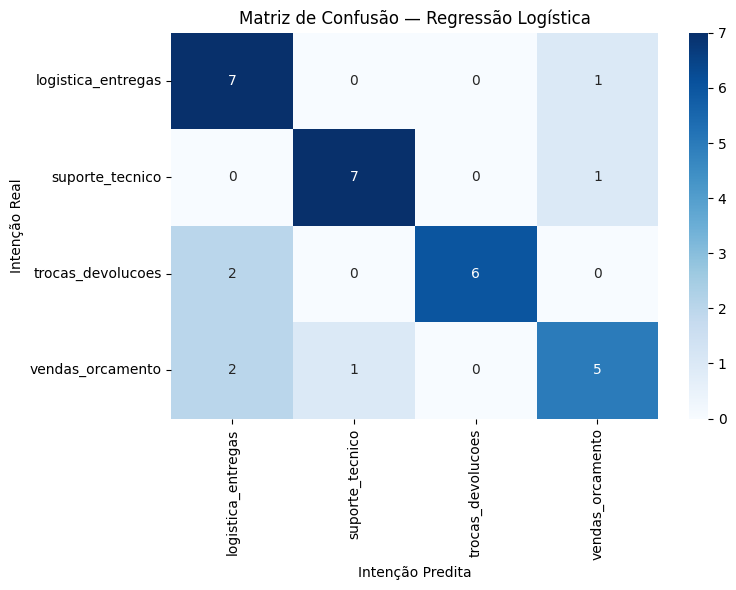


TESTES DO CHATBOT

Mensagem:
quero devolver meu sofá
Resultado:
FALLBACK_HUMANO
Confiança: 25.01%

Mensagem:
como faço para realizar a devolução?
Resultado:
FALLBACK_HUMANO
Confiança: 25.00%

Mensagem:
cadê meu pedido?
Resultado:
FALLBACK_HUMANO
Confiança: 25.01%

Mensagem:
meu pedido nao chego
Resultado:
FALLBACK_HUMANO
Confiança: 25.02%

Mensagem:
qual é a previsão do tempo?
Resultado:
FALLBACK_HUMANO
Confiança: 25.00%

ANÁLISE DA MENSAGEM

Mensagem original:
qual é a previsão do tempo?

Mensagem processada:
previsão tempo

Probabilidades:
logistica_entregas       : 25.00%
suporte_tecnico          : 25.00%
trocas_devolucoes        : 25.00%
vendas_orcamento         : 25.00%

Intenção mais provável:
suporte_tecnico

Confiança:
25.00%

Limiar utilizado:
50.00%

Decisão final:
FALLBACK_HUMANO

TESTES ADICIONAIS

Mensagem: quero trocar meu sofá
Resultado: FALLBACK_HUMANO
Confiança: 25.00%
----------------------------------------------------------------------

Mensagem: onde está minha me

,mensagem,resultado,confianca
0,Qual é a previsão do tempo para amanhã?,FALLBACK_HUMANO,0.250051
1,Quero aprender a tocar violão,FALLBACK_HUMANO,0.250005
2,Me explique como funciona Bitcoin,FALLBACK_HUMANO,0.250040
3,Quem ganhou o campeonato brasileiro?,FALLBACK_HUMANO,0.250035
4,Qual será o clima no final de semana?,FALLBACK_HUMANO,0.250043
5,Quais filmes estão passando hoje?,FALLBACK_HUMANO,0.250048
6,Qual é a melhor linguagem de programação?,FALLBACK_HUMANO,0.250028
7,Me ensine a fazer um bolo de chocolate,FALLBACK_HUMANO,0.250011
8,Como faço uma receita de lasanha?,FALLBACK_HUMANO,0.250012
9,Qual é o melhor celular atualmente?,FALLBACK_HUMANO,0.250015


In [41]:
#Exercício 3 — Classificador de Intenções com Fallback

print("Formato dos dados:")
print("X_treino_vec:", X_treino_vec.shape)
print("X_teste_vec :", X_teste_vec.shape)
print("y_treino    :", y_treino.shape)
print("y_teste     :", y_teste.shape)


# ============================================================
# 1. TREINAMENTO DA REGRESSÃO LOGÍSTICA
# ============================================================

modelo_logistico = LogisticRegression(
    max_iter=1000
)

modelo_logistico.fit(
    X_treino_vec,
    y_treino
)

print("\nRegressão Logística treinada com sucesso.")

print("\nClasses aprendidas pelo modelo:")
print(modelo_logistico.classes_)


# ============================================================
# 2. PREVISÕES NO CONJUNTO DE TESTE
# ============================================================

y_pred = modelo_logistico.predict(
    X_teste_vec
)

print("\nPrevisões realizadas com sucesso.")

print("\nPrimeiras previsões:")
print(y_pred[:10])


# ============================================================
# 3. RELATÓRIO DE CLASSIFICAÇÃO
# ============================================================

print("\n" + "=" * 70)
print("RELATÓRIO DE CLASSIFICAÇÃO — REGRESSÃO LOGÍSTICA")
print("=" * 70)

print(
    classification_report(
        y_teste,
        y_pred
    )
)


# ============================================================
# 4. MÉTRICAS
# ============================================================

accuracy = accuracy_score(
    y_teste,
    y_pred
)

precision = precision_score(
    y_teste,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_teste,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_teste,
    y_pred,
    average="weighted"
)

print("Métricas:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


# ============================================================
# 5. MATRIZ DE CONFUSÃO
# ============================================================

cm = confusion_matrix(
    y_teste,
    y_pred,
    labels=modelo_logistico.classes_
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=modelo_logistico.classes_,
    yticklabels=modelo_logistico.classes_
)

plt.xlabel("Intenção Predita")
plt.ylabel("Intenção Real")
plt.title("Matriz de Confusão — Regressão Logística")

plt.tight_layout()
plt.show()


# ============================================================
# 6. FUNÇÃO DE CLASSIFICAÇÃO COM FALLBACK
# ============================================================

def classificar_mensagem(
    mensagem,
    modelo,
    modelo_embedding,
    limiar=0.50
):
    """
    Classifica uma mensagem utilizando Regressão Logística
    e aplica fallback quando a confiança for inferior ao
    limiar definido.

    Parâmetros:
        mensagem          -> texto recebido pelo chatbot
        modelo            -> modelo de classificação treinado
        modelo_embedding  -> modelo FastText
        limiar            -> confiança mínima para classificação

    Retorna:
        resultado         -> intenção ou FALLBACK_HUMANO
        confianca         -> probabilidade da classe escolhida
    """

    # --------------------------------------------------------
    # 1. Pré-processar a mensagem
    # --------------------------------------------------------

    texto_processado = limpar_e_lemmatizar(mensagem)

    # --------------------------------------------------------
    # 2. Verificar se não restaram tokens
    # --------------------------------------------------------

    if not texto_processado.strip():

        return "FALLBACK_HUMANO", 0.0

    # --------------------------------------------------------
    # 3. Transformar a mensagem em vetor
    # --------------------------------------------------------

    vetor = obter_vetor_frase(
        texto_processado,
        modelo_embedding
    )

    # --------------------------------------------------------
    # 4. Ajustar o formato para o modelo
    # --------------------------------------------------------

    vetor = vetor.reshape(1, -1)

    # --------------------------------------------------------
    # 5. Obter as probabilidades
    # --------------------------------------------------------

    probabilidades = modelo.predict_proba(vetor)[0]

    # --------------------------------------------------------
    # 6. Encontrar a classe com maior probabilidade
    # --------------------------------------------------------

    indice_maximo = np.argmax(probabilidades)

    intencao_predita = modelo.classes_[indice_maximo]

    confianca = probabilidades[indice_maximo]

    # --------------------------------------------------------
    # 7. Aplicar a regra de fallback
    #
    # Confiança >= 50% -> intenção
    # Confiança < 50%  -> FALLBACK_HUMANO
    # --------------------------------------------------------

    if confianca >= limiar:

        resultado = intencao_predita

    else:

        resultado = "FALLBACK_HUMANO"

    # --------------------------------------------------------
    # 8. Retornar resultado
    # --------------------------------------------------------

    return resultado, confianca


# ============================================================
# 7. TESTES SOLICITADOS PELO EXERCÍCIO
# ============================================================

testes = [
    "quero devolver meu sofá",
    "como faço para realizar a devolução?",
    "cadê meu pedido?",
    "meu pedido nao chego",
    "qual é a previsão do tempo?"
]

print("\n" + "=" * 70)
print("TESTES DO CHATBOT")
print("=" * 70)

for mensagem in testes:

    resultado, confianca = classificar_mensagem(
        mensagem,
        modelo_logistico,
        modelo_fasttext,
        limiar=0.50
    )

    print("\nMensagem:")
    print(mensagem)

    print("Resultado:")
    print(resultado)

    print(f"Confiança: {confianca:.2%}")


# ============================================================
# 8. FUNÇÃO DE DIAGNÓSTICO DO CLASSIFICADOR
# ============================================================

def analisar_classificacao(
    mensagem,
    modelo,
    modelo_embedding,
    limiar=0.50
):
    """
    Mostra detalhadamente o processo de classificação.
    """

    texto_processado = limpar_e_lemmatizar(mensagem)

    print("\n" + "=" * 70)
    print("ANÁLISE DA MENSAGEM")
    print("=" * 70)

    print("\nMensagem original:")
    print(mensagem)

    print("\nMensagem processada:")
    print(texto_processado)

    # --------------------------------------------------------
    # Mensagem sem tokens
    # --------------------------------------------------------

    if not texto_processado.strip():

        print("\nIntenção mais provável:")
        print("Nenhuma")

        print("\nConfiança:")
        print("0.00%")

        print("\nDecisão final:")
        print("FALLBACK_HUMANO")

        return

    # --------------------------------------------------------
    # Gerar vetor
    # --------------------------------------------------------

    vetor = obter_vetor_frase(
        texto_processado,
        modelo_embedding
    )

    vetor = vetor.reshape(1, -1)

    # --------------------------------------------------------
    # Probabilidades
    # --------------------------------------------------------

    probabilidades = modelo.predict_proba(vetor)[0]

    indice_maximo = np.argmax(probabilidades)

    intencao = modelo.classes_[indice_maximo]

    confianca = probabilidades[indice_maximo]

    # --------------------------------------------------------
    # Aplicar fallback
    # --------------------------------------------------------

    if confianca >= limiar:

        resultado = intencao

    else:

        resultado = "FALLBACK_HUMANO"

    # --------------------------------------------------------
    # Mostrar probabilidades
    # --------------------------------------------------------

    print("\nProbabilidades:")

    for classe, probabilidade in zip(
        modelo.classes_,
        probabilidades
    ):

        print(
            f"{classe:<25}: "
            f"{probabilidade:.2%}"
        )

    print("\nIntenção mais provável:")
    print(intencao)

    print("\nConfiança:")
    print(f"{confianca:.2%}")

    print("\nLimiar utilizado:")
    print(f"{limiar:.2%}")

    print("\nDecisão final:")
    print(resultado)


# ============================================================
# 9. DIAGNÓSTICO DE UMA MENSAGEM OOD
# ============================================================

analisar_classificacao(
    "qual é a previsão do tempo?",
    modelo_logistico,
    modelo_fasttext,
    limiar=0.50
)


# ============================================================
# 10. TESTES ADICIONAIS
# ============================================================

testes_adicionais = [
    "quero trocar meu sofá",
    "onde está minha mesa?",
    "preciso do manual do rack",
    "quanto custa uma poltrona?",
    "qual é a capital da França?",
    "me ensine a fazer bolo",
    "qual será o clima amanhã?",
    "quero acompanhar meu pedido"
]

print("\n" + "=" * 70)
print("TESTES ADICIONAIS")
print("=" * 70)

for mensagem in testes_adicionais:

    resultado, confianca = classificar_mensagem(
        mensagem,
        modelo_logistico,
        modelo_fasttext,
        limiar=0.50
    )

    print(f"\nMensagem: {mensagem}")
    print(f"Resultado: {resultado}")
    print(f"Confiança: {confianca:.2%}")
    print("-" * 70)


# ============================================================
# 11. AVALIAÇÃO DAS MENSAGENS OOD / FALLBACK
# ============================================================

resultados_ood = []

for mensagem in df_ood["mensagem"]:

    resultado, confianca = classificar_mensagem(
        mensagem,
        modelo_logistico,
        modelo_fasttext,
        limiar=0.50
    )

    resultados_ood.append({
        "mensagem": mensagem,
        "resultado": resultado,
        "confianca": confianca
    })


# ============================================================
# 12. TRANSFORMAR RESULTADOS EM DATAFRAME
# ============================================================

df_resultados_ood = pd.DataFrame(
    resultados_ood
)


# ============================================================
# 13. CALCULAR TAXA DE FALLBACK
# ============================================================

total_ood = len(df_resultados_ood)

total_fallback = (
    df_resultados_ood["resultado"] == "FALLBACK_HUMANO"
).sum()

total_classificado = (
    df_resultados_ood["resultado"] != "FALLBACK_HUMANO"
).sum()

taxa_fallback = (
    total_fallback / total_ood
    if total_ood > 0
    else 0
)


# ============================================================
# 14. RESULTADO DA AVALIAÇÃO OOD
# ============================================================

print("\n" + "=" * 70)
print("AVALIAÇÃO OOD / FALLBACK")
print("=" * 70)

print(f"\nTotal de mensagens OOD: {total_ood}")

print(
    f"Total encaminhado para fallback: "
    f"{total_fallback}"
)

print(
    f"Total classificado automaticamente: "
    f"{total_classificado}"
)

print(
    f"Taxa de fallback: "
    f"{taxa_fallback:.2%}"
)


# ============================================================
# 15. EXIBIR RESULTADOS OOD
# ============================================================

print("\nResultados individuais:")

display(
    df_resultados_ood
)


In [37]:
#Exercício 4 — Laboratório Comparativo: Regressão Logística × KNN

modelo_logistico = LogisticRegression(
    max_iter=1000
)

modelo_knn = KNeighborsClassifier(
    n_neighbors=3
)

modelo_logistico.fit(
    X_treino_vec,
    y_treino
)

modelo_knn.fit(
    X_treino_vec,
    y_treino
)

print("Modelos treinados com sucesso.")


y_pred_logistico = modelo_logistico.predict(
    X_teste_vec
)

y_pred_knn = modelo_knn.predict(
    X_teste_vec
)


# Regressão Logística

accuracy_logistico = accuracy_score(
    y_teste,
    y_pred_logistico
)

precision_logistico = precision_score(
    y_teste,
    y_pred_logistico,
    average="weighted"
)

recall_logistico = recall_score(
    y_teste,
    y_pred_logistico,
    average="weighted"
)

f1_logistico = f1_score(
    y_teste,
    y_pred_logistico,
    average="weighted"
)


# KNN

accuracy_knn = accuracy_score(
    y_teste,
    y_pred_knn
)

precision_knn = precision_score(
    y_teste,
    y_pred_knn,
    average="weighted"
)

recall_knn = recall_score(
    y_teste,
    y_pred_knn,
    average="weighted"
)

f1_knn = f1_score(
    y_teste,
    y_pred_knn,
    average="weighted"
)



resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "KNN"
    ],

    "Accuracy": [
        accuracy_logistico,
        accuracy_knn
    ],

    "Precision": [
        precision_logistico,
        precision_knn
    ],

    "Recall": [
        recall_logistico,
        recall_knn
    ],

    "F1": [
        f1_logistico,
        f1_knn
    ]
})

resultados


resultados_formatados = resultados.copy()

for coluna in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]:
    resultados_formatados[coluna] = (
        resultados_formatados[coluna] * 100
    ).round(2).astype(str) + "%"

resultados_formatados


#=========================================

print("RELATÓRIO — KNN")
print(
    classification_report(
        y_teste,
        y_pred_knn
    )
)

# ============================================================
# TABELA FINAL — COMPARAÇÃO DOS MODELOS
# ============================================================

tabela_final = resultados.copy()

for coluna in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]:
    tabela_final[coluna] = (
        tabela_final[coluna] * 100
    ).round(2).astype(str) + "%"

print("=" * 70)
print("COMPARAÇÃO — REGRESSÃO LOGÍSTICA × KNN")
print("=" * 70)

print(tabela_final)



Modelos treinados com sucesso.
RELATÓRIO — KNN
                    precision    recall  f1-score   support

logistica_entregas       0.67      0.75      0.71         8
   suporte_tecnico       0.75      0.75      0.75         8
 trocas_devolucoes       0.78      0.88      0.82         8
  vendas_orcamento       0.67      0.50      0.57         8

          accuracy                           0.72        32
         macro avg       0.72      0.72      0.71        32
      weighted avg       0.72      0.72      0.71        32

COMPARAÇÃO — REGRESSÃO LOGÍSTICA × KNN
                Modelo Accuracy Precision  Recall      F1
0  Regressão Logística   78.12%    80.64%  78.12%  78.39%
1                  KNN   71.88%    71.53%  71.88%  71.27%
